In [ ]:
# 🔷 1. គំនិត Project (Clustering)

# 👉 Clustering គឺជា Unsupervised Learning
# មានន័យថា៖

# មិនមាន label (y)
# Model នឹង បែងចែកក្រុម (Group) ដោយខ្លួនឯង

# 📌 ក្នុង dataset Online Retail
# យើងអាចធ្វើ:

# ចែកក្រុម Customer
# ឬ Product

# 👉 Example:

# Customer VIP
# Customer Normal
# Customer Low spending
# 🔷 2. Install Library (ក្នុង Jupyter)
# !pip install pandas numpy matplotlib seaborn scikit-learn openpyxl

In [2]:
# 🔷 3. Import Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [4]:
# 🔷 4. Load Dataset
df = pd.read_excel("Online Retail.xlsx")

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [7]:
# 🔷 5. សម្អាត Data (Data Cleaning)
# លុប missing values
df = df.dropna()

# បង្កើត Total Price
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

In [8]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,10.20
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60


In [10]:
# 🔷 6. បង្កើត Customer Feature

# 👉 យើងនឹង Group តាម CustomerID

customer_data = df.groupby("CustomerID").agg({
    "InvoiceNo": "count",   # ចំនួនការទិញ
    "Quantity": "sum",      # ចំនួនទំនិញ
    "TotalPrice": "sum"     # ចំណាយសរុប
})

customer_data.columns = ["Frequency", "Quantity", "TotalSpent"]

customer_data.head()

,Frequency,Quantity,TotalSpent
CustomerID,,,
12346.0,2,0,0.00
12347.0,182,2458,4310.00
12348.0,31,2341,1797.24
12349.0,73,631,1757.55
12350.0,17,197,334.40


In [11]:
# 🔷 7. Feature Scaling

# 👉 សំខាន់ណាស់ (KMeans ត្រូវការតម្លៃស្មើៗគ្នា)

scaler = StandardScaler()
scaled_data = scaler.fit_transform(customer_data)
scaled_data

array([[-0.3917197 , -0.24021456, -0.23100099],
       [ 0.38265697,  0.28586959,  0.29343167],
       [-0.26695902,  0.26082816, -0.01231622],
       ...,
       [-0.34439668, -0.21923969, -0.20951263],
       [ 2.85205812,  0.05878444,  0.02390005],
       [-0.0991774 ,  0.09923599, -0.00744423]], shape=(4372, 3))

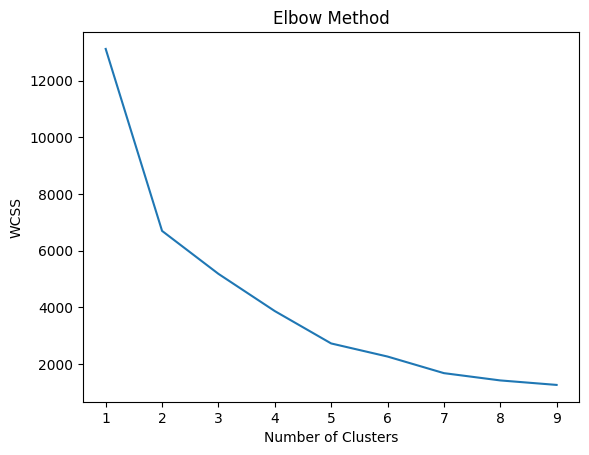

In [12]:
# 🔷 8. រក K (Elbow Method)
wcss = []

for i in range(1, 10):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 10), wcss)
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

# 👉 ចំណុចដែលកោង (elbow) = K ល្អ
# 👉 ត្រឹមត្រូវគឺ៖
# 👉 មើលចំណុចដែល “ចាប់ផ្តើមចុះយឺត”

# 🔷 ពន្យល់ងាយៗ
# ដំបូង (K=1 → 2 → 3)
# 👉 WCSS ចុះលឿន 🔽🔽🔽
# បន្ទាប់ (K=4 → 5 → 6)
# 👉 ចុះតិចៗ 🔽

# 👉 ចំណុច “បម្លែង” នេះ = Elbow

In [16]:
# 🔷 9. Train K-Means Model

# 👉 ឧទាហរណ៍ K = 3

kmeans = KMeans(n_clusters=4, random_state=42)
customer_data["Cluster"] = kmeans.fit_predict(scaled_data)

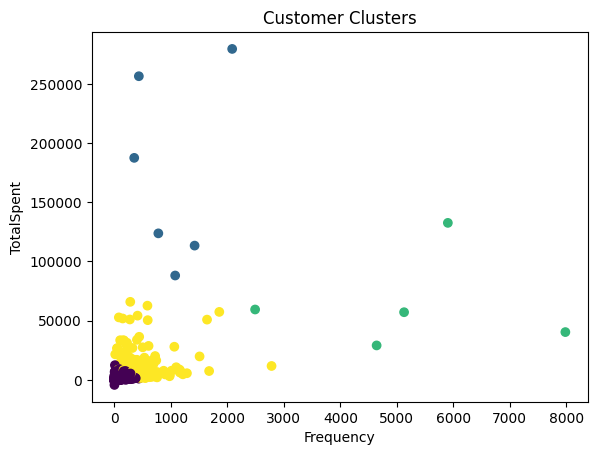

In [17]:
# 🔷 10. Visualization
plt.scatter(customer_data["Frequency"], customer_data["TotalSpent"], 
            c=customer_data["Cluster"], cmap='viridis')

plt.xlabel("Frequency")
plt.ylabel("TotalSpent")
plt.title("Customer Clusters")
plt.show()

In [15]:
# 🔷 11. Analyze Result
print(customer_data.groupby("Cluster").mean())

# 👉 អ្នកអាចយល់ថា:

# Cluster 0 → VIP
# Cluster 1 → Normal
# Cluster 2 → Low

           Frequency      Quantity     TotalSpent
Cluster                                          
0          84.387193    928.354372    1549.295420
1         961.142857  84136.000000  158756.821429
2        4053.250000  34137.000000   54810.990000


In [ ]:
# 🔷 12. Interpretation (សម្រាប់ Report)

# 📌 Example:

# Cluster 0:
# ចំណាយច្រើន
# ទិញញឹកញាប់
# 👉 VIP Customer
# Cluster 1:
# 👉 Customer មធ្យម
# Cluster 2:
# 👉 Customer ថ្មី ឬ ទិញតិច